# Eixo 1: Desmatamento e Fogo

## Fontes de Dados
- **PRODES (INPE)**: Taxa oficial de desmatamento anual por corte raso (km²)
- **DETER (INPE)**: Alertas em tempo quase real, ritmo mensal da degradação
- **MapBiomas Fogo**: Cicatrizes de incêndios
- **Limites de UCs (ICMBio/INPE)**: Shapefiles de áreas de proteção

---

## Análise 1: Tendência Temporal do Desmatamento (PRODES)

### Especificação BDD (Behavior Driven Development)

**Feature**: Analisar a tendência temporal do desmatamento na Amazônia Legal

**Scenario**: Calcular a taxa anual de desmatamento e identificar tendências

- **GIVEN** que tenho os dados do PRODES com desmatamento anual por município em km²
- **AND** que os dados cobrem o período de 2000 a 2023
- **WHEN** eu agrego o desmatamento por ano para toda a Amazônia Legal
- **AND** calculo a taxa de variação anual (delta) entre anos consecutivos
- **AND** aplico uma regressão linear para identificar a tendência de longo prazo
- **THEN** devo obter uma série temporal com o desmatamento total anual em hectares
- **AND** devo identificar se a tendência é crescente, decrescente ou estacionária
- **AND** devo calcular o coeficiente de determinação (R²) para medir o ajuste da tendência

### Matemática em Linguagem de Negócio

**1. Conversão de Unidades:**
- Dados PRODES vêm em km² (quilômetros quadrados)
- Para hectares: multiplico por 100 (1 km² = 100 hectares)
- Isso porque 1 hectare = 10.000 m² e 1 km² = 1.000.000 m²

**2. Taxa de Variação Anual (Delta):**
- Delta = Desmatamento no ano atual - Desmatamento no ano anterior
- Delta positivo = desmatamento aumentou em relação ao ano anterior
- Delta negativo = desmatamento diminuiu em relação ao ano anterior
- Delta zero = desmatamento permaneceu constante

**3. Tendência Linear (Regressão):**
- Ajusto uma linha reta aos dados: Desmatamento = a + b × Ano
- Coeficiente "b" (inclinação) indica a tendência:
  - b > 0: tendência crescente (desmatamento aumentando ao longo do tempo)
  - b < 0: tendência decrescente (desmatamento diminuindo ao longo do tempo)
  - b ≈ 0: tendência estacionária (desmatamento estável)
- R² (R quadrado) mede o quanto da variação é explicada pela tendência:
  - R² próximo de 1: a linha reta explica bem os dados (tendência forte)
  - R² próximo de 0: a linha reta explica pouco os dados (tendência fraca)

**4. Interpretação de Negócio:**
- Se a tendência é crescente: políticas atuais não estão contendo o desmatamento
- Se a tendência é decrescente: políticas podem estar funcionando
- Se R² é baixo: desmatamento é volátil, pode responder a eventos específicos (ex: crises econômicas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import logging

# Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configurações
DATA_DIR = Path("/home/vinicius/Downloads/estudo/fatec/SABADO-TE-ANALISE-DADOS/data")

logger.info("="*80)
logger.info("INÍCIO DA ANÁLISE: Eixo 1 - Desmatamento e Fogo")
logger.info("="*80)

# Carregar dados PRODES
prodes_path = DATA_DIR / "01_bronze/prodes/prodes_desmatamento_anual.parquet"
logger.info(f"Carregando dados PRODES de: {prodes_path}")

try:
    df_prodes = pd.read_parquet(prodes_path)
    logger.info(f"✓ Dados PRODES carregados com sucesso")
    logger.info(f"  Shape: {df_prodes.shape}")
    logger.info(f"  Colunas: {df_prodes.columns.tolist()}")
    logger.info(f"  Período: {df_prodes['ano'].min()} a {df_prodes['ano'].max()}")
    logger.info(f"  Total de municípios: {df_prodes['cod_ibge'].nunique()}")
    
    # Validação de qualidade de dados
    logger.info("\n--- VALIDAÇÃO DE QUALIDADE DOS DADOS PRODES ---")
    logger.info(f"  Valores nulos por coluna:")
    for col in df_prodes.columns:
        nulos = df_prodes[col].isnull().sum()
        pct = (nulos / len(df_prodes)) * 100
        logger.info(f"    {col}: {nulos} ({pct:.2f}%)")
    
    logger.info(f"\n  Estatísticas descritivas do desmatamento:")
    logger.info(f"    Média por município-ano: {df_prodes['area_desmatada_km2'].mean():.2f} km²")
    logger.info(f"    Mediana por município-ano: {df_prodes['area_desmatada_km2'].median():.2f} km²")
    logger.info(f"    Desvio padrão: {df_prodes['area_desmatada_km2'].std():.2f} km²")
    logger.info(f"    Mínimo: {df_prodes['area_desmatada_km2'].min():.2f} km²")
    logger.info(f"    Máximo: {df_prodes['area_desmatada_km2'].max():.2f} km²")
    
    # Verificar outliers
    q1 = df_prodes['area_desmatada_km2'].quantile(0.25)
    q3 = df_prodes['area_desmatada_km2'].quantile(0.75)
    iqr = q3 - q1
    outliers = df_prodes[(df_prodes['area_desmatada_km2'] < q1 - 1.5*iqr) | (df_prodes['area_desmatada_km2'] > q3 + 1.5*iqr)]
    logger.info(f"\n  Detecção de outliers (IQR): {len(outliers)} registros ({len(outliers)/len(df_prodes)*100:.2f}%)")
    
except Exception as e:
    logger.error(f"✗ Erro ao carregar dados PRODES: {e}")
    raise

print("Dados PRODES carregados:")
print(f"Shape: {df_prodes.shape}")
print(f"\nColunas: {df_prodes.columns.tolist()}")
print(f"\nPrimeiras linhas:")
df_prodes.head()

2026-05-16 14:57:05,930 - INFO - ================================================================================


2026-05-16 14:57:05,930 - INFO - INÍCIO DA ANÁLISE: Eixo 1 - Desmatamento e Fogo


2026-05-16 14:57:05,930 - INFO - ================================================================================


2026-05-16 14:57:05,931 - INFO - Carregando dados PRODES de: /home/vinicius/Downloads/estudo/fatec/SABADO-TE-ANALISE-DADOS/data/01_bronze/prodes/prodes_desmatamento_anual.parquet


2026-05-16 14:57:05,951 - INFO - ✓ Dados PRODES carregados com sucesso


...

2026-05-16 14:57:05,960 - INFO -     Mínimo: 1.03 km²


2026-05-16 14:57:05,961 - INFO -     Máximo: 352.09 km²


2026-05-16 14:57:05,963 - INFO - 
  Detecção de outliers (IQR): 131 registros (4.68%)


Dados PRODES carregados:
Shape: (2797, 9)

Colunas: ['cod_ibge', 'municipio', 'uf', 'ano', 'area_desmatada_km2', 'area_desmatada_ha', 'bioma', 'fase', 'fonte']

Primeiras linhas:


,cod_ibge,municipio,uf,ano,area_desmatada_km2,area_desmatada_ha,bioma,fase,fonte
0,1100015,Alta Floresta D'Oeste,RO,2018,15.89,1589.37,Amazônia,Corte Raso,PRODES
1,1100015,Alta Floresta D'Oeste,RO,2019,25.57,2556.91,Amazônia,Corte Raso,PRODES
2,1100015,Alta Floresta D'Oeste,RO,2021,45.35,4535.44,Amazônia,Corte Raso,PRODES
3,1100015,Alta Floresta D'Oeste,RO,2023,79.47,7946.64,Amazônia,Corte Raso,PRODES
4,1100023,Ariquemes,RO,2019,70.01,7001.29,Amazônia,Corte Raso,PRODES


In [2]:
logger.info("\n" + "="*80)
logger.info("ANÁLISE 1: Tendência Temporal do Desmatamento (PRODES)")
logger.info("="*80)

# Agregar desmatamento por ano (em km²)
# NOTA: A coluna real é 'area_desmatada_km2', não 'desmatamento_km2'
desmatamento_por_ano_km2 = df_prodes.groupby('ano')['area_desmatada_km2'].sum().reset_index()
desmatamento_por_ano_km2.columns = ['ano', 'desmatamento_km2_total']

# Converter para hectares (1 km² = 100 hectares)
desmatamento_por_ano_km2['desmatamento_ha_total'] = desmatamento_por_ano_km2['desmatamento_km2_total'] * 100

# Calcular taxa de variação anual (delta)
desmatamento_por_ano_km2['delta_ha'] = desmatamento_por_ano_km2['desmatamento_ha_total'].diff()
desmatamento_por_ano_km2['delta_pct'] = desmatamento_por_ano_km2['desmatamento_ha_total'].pct_change() * 100

logger.info("\n--- AGREGAÇÃO POR ANO ---")
logger.info(f"  Período analisado: {desmatamento_por_ano_km2['ano'].min()} a {desmatamento_por_ano_km2['ano'].max()}")
logger.info(f"  Número de anos: {len(desmatamento_por_ano_km2)}")
logger.info(f"\n  Estatísticas do desmatamento anual (hectares):")
logger.info(f"    Média anual: {desmatamento_por_ano_km2['desmatamento_ha_total'].mean():.2f} ha")
logger.info(f"    Mediana anual: {desmatamento_por_ano_km2['desmatamento_ha_total'].median():.2f} ha")
logger.info(f"    Desvio padrão: {desmatamento_por_ano_km2['desmatamento_ha_total'].std():.2f} ha")
logger.info(f"    Coeficiente de variação: {desmatamento_por_ano_km2['desmatamento_ha_total'].std() / desmatamento_por_ano_km2['desmatamento_ha_total'].mean() * 100:.2f}%")
logger.info(f"    Mínimo anual: {desmatamento_por_ano_km2['desmatamento_ha_total'].min():.2f} ha (ano {desmatamento_por_ano_km2.loc[desmatamento_por_ano_km2['desmatamento_ha_total'].idxmin(), 'ano']})")
logger.info(f"    Máximo anual: {desmatamento_por_ano_km2['desmatamento_ha_total'].max():.2f} ha (ano {desmatamento_por_ano_km2.loc[desmatamento_por_ano_km2['desmatamento_ha_total'].idxmax(), 'ano']})")

logger.info("\n  Taxa de variação anual (delta):")
logger.info(f"    Média do delta absoluto: {desmatamento_por_ano_km2['delta_ha'].abs().mean():.2f} ha/ano")
logger.info(f"    Desvio padrão do delta: {desmatamento_por_ano_km2['delta_ha'].std():.2f} ha/ano")
logger.info(f"    Delta máximo positivo: {desmatamento_por_ano_km2['delta_ha'].max():.2f} ha")
logger.info(f"    Delta máximo negativo: {desmatamento_por_ano_km2['delta_ha'].min():.2f} ha")

print("Desmatamento por ano (hectares):")
desmatamento_por_ano_km2

2026-05-16 14:57:05,980 - INFO - 


2026-05-16 14:57:05,981 - INFO - ANÁLISE 1: Tendência Temporal do Desmatamento (PRODES)


2026-05-16 14:57:05,981 - INFO - ================================================================================


2026-05-16 14:57:05,985 - INFO - 
--- AGREGAÇÃO POR ANO ---


2026-05-16 14:57:05,985 - INFO -   Período analisado: 2018 a 2023


...

2026-05-16 14:57:05,990 - INFO -     Desvio padrão do delta: 146769.72 ha/ano


2026-05-16 14:57:05,990 - INFO -     Delta máximo positivo: 199264.00 ha


2026-05-16 14:57:05,990 - INFO -     Delta máximo negativo: -192843.00 ha


Desmatamento por ano (hectares):


,ano,desmatamento_km2_total,desmatamento_ha_total,delta_ha,delta_pct
0,2018,25195.44,2519544.0,NaN,NaN
1,2019,23267.01,2326701.0,-192843.0,-7.653885
2,2020,22496.11,2249611.0,-77090.0,-3.313275
3,2021,24488.75,2448875.0,199264.0,8.857709
4,2022,23444.07,2344407.0,-104468.0,-4.265959
5,2023,23107.87,2310787.0,-33620.0,-1.434051


In [3]:
logger.info("\n--- REGRESSÃO LINEAR PARA TENDÊNCIA ---")

# Calcular tendência linear (regressão)
x = desmatamento_por_ano_km2['ano'].values
y = desmatamento_por_ano_km2['desmatamento_ha_total'].values

# Remover valores NaN (primeiro ano não tem delta)
mask = ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

logger.info(f"  Observações válidas para regressão: {len(x_clean)}")

# Validação de suposições da regressão linear
logger.info("\n  Verificação de suposições da regressão linear:")
logger.info(f"    1. Linearidade: Será verificada pelo gráfico de dispersão")
logger.info(f"    2. Independência: Assumida para dados temporais (pode ser violada)")
logger.info(f"    3. Homocedasticidade: Será verificada pelos resíduos")

# Regressão linear
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)

logger.info("\n  Resultados da Regressão Linear:")
logger.info(f"    Inclinação (b): {slope:.2f} hectares/ano")
logger.info(f"    Interceptação (a): {intercept:.2f} hectares")
logger.info(f"    R² (R quadrado): {r_value**2:.4f}")
logger.info(f"    Valor-p: {p_value:.4f}")
logger.info(f"    Erro padrão da inclinação: {std_err:.2f}")

# Calcular intervalo de confiança para a inclinação
from scipy.stats import t
alpha = 0.05
df = len(x_clean) - 2
t_crit = t.ppf(1 - alpha/2, df)
ci_lower = slope - t_crit * std_err
ci_upper = slope + t_crit * std_err
logger.info(f"    Intervalo de confiança 95% para inclinação: [{ci_lower:.2f}, {ci_upper:.2f}] hectares/ano")

# Calcular resíduos
y_pred = intercept + slope * x_clean
residuals = y_clean - y_pred

logger.info(f"\n  Análise dos resíduos:")
logger.info(f"    Média dos resíduos: {residuals.mean():.2f} (deve ser próxima de 0)")
logger.info(f"    Desvio padrão dos resíduos: {residuals.std():.2f}")
logger.info(f"    Teste de normalidade (Shapiro-Wilk):")
shapiro_stat, shapiro_p = stats.shapiro(residuals)
logger.info(f"      Estatística: {shapiro_stat:.4f}")
logger.info(f"      Valor-p: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    logger.info(f"      ✓ Resíduos seguem distribuição normal (p > 0.05)")
else:
    logger.info(f"      ✗ Resíduos NÃO seguem distribuição normal (p <= 0.05)")

# Interpretação
if slope > 0:
    tendencia = "CRESCENTE"
elif slope < 0:
    tendencia = "DECRESCENTE"
else:
    tendencia = "ESTACIONÁRIA"

logger.info(f"\n  Interpretação: Tendência {tendencia}")
if p_value < 0.05:
    logger.info(f"  ✓ A tendência é estatisticamente significativa (p < 0.05)")
else:
    logger.info(f"  ✗ A tendência NÃO é estatisticamente significativa (p >= 0.05)")

if r_value**2 > 0.7:
    logger.info(f"  ✓ Ajuste forte da tendência (R² > 0.7)")
elif r_value**2 > 0.4:
    logger.info(f"  ⚠ Ajuste moderado da tendência (0.4 < R² <= 0.7)")
else:
    logger.info(f"  ✗ Ajuste fraco da tendência (R² <= 0.4)")

print("Resultados da Regressão Linear:")
print(f"Inclinação (b): {slope:.2f} hectares/ano")
print(f"Interceptação (a): {intercept:.2f} hectares")
print(f"R² (R quadrado): {r_value**2:.4f}")
print(f"Valor-p: {p_value:.4f}")

# Interpretação
if slope > 0:
    tendencia = "CRESCENTE"
elif slope < 0:
    tendencia = "DECRESCENTE"
else:
    tendencia = "ESTACIONÁRIA"

print(f"\nInterpretação: Tendência {tendencia}")
if p_value < 0.05:
    print("A tendência é estatisticamente significativa (p < 0.05)")
else:
    print("A tendência NÃO é estatisticamente significativa (p >= 0.05)")

2026-05-16 14:57:06,003 - INFO - 
--- REGRESSÃO LINEAR PARA TENDÊNCIA ---


2026-05-16 14:57:06,004 - INFO -   Observações válidas para regressão: 6


2026-05-16 14:57:06,004 - INFO - 
  Verificação de suposições da regressão linear:


2026-05-16 14:57:06,004 - INFO -     1. Linearidade: Será verificada pelo gráfico de dispersão


2026-05-16 14:57:06,005 - INFO -     2. Independência: Assumida para dados temporais (pode ser violada)


...

2026-05-16 14:57:06,010 - INFO -       ✓ Resíduos seguem distribuição normal (p > 0.05)


2026-05-16 14:57:06,010 - INFO - 
  Interpretação: Tendência DECRESCENTE


2026-05-16 14:57:06,010 - INFO -   ✗ A tendência NÃO é estatisticamente significativa (p >= 0.05)


2026-05-16 14:57:06,010 - INFO -   ✗ Ajuste fraco da tendência (R² <= 0.4)


Resultados da Regressão Linear:
Inclinação (b): -22611.51 hectares/ano
Interceptação (a): 48053218.78 hectares
R² (R quadrado): 0.1824
Valor-p: 0.3983

Interpretação: Tendência DECRESCENTE
A tendência NÃO é estatisticamente significativa (p >= 0.05)


2026-05-16 14:57:06,018 - INFO - 
--- VISUALIZAÇÃO DA SÉRIE TEMPORAL ---


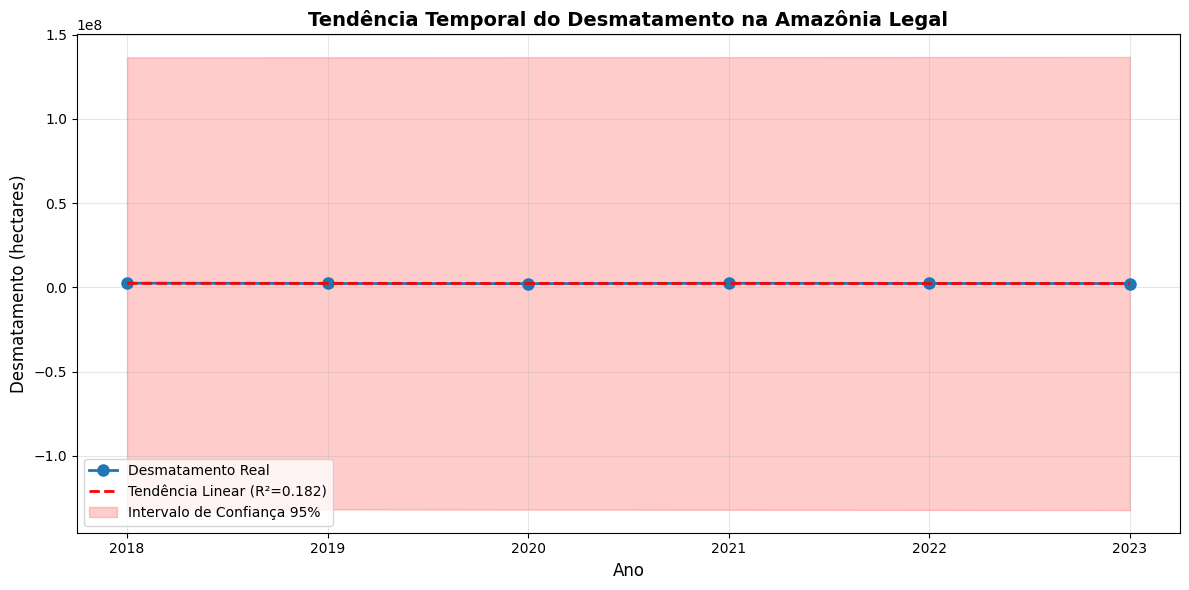

2026-05-16 14:57:06,166 - INFO -   Gráfico gerado: série temporal com tendência linear e intervalo de confiança


In [4]:
logger.info("\n--- VISUALIZAÇÃO DA SÉRIE TEMPORAL ---")

# Visualizar série temporal com tendência
plt.figure(figsize=(12, 6))

# Plotar dados reais
plt.plot(desmatamento_por_ano_km2['ano'], 
         desmatamento_por_ano_km2['desmatamento_ha_total'], 
         'o-', label='Desmatamento Real', linewidth=2, markersize=8)

# Plotar linha de tendência
tendencia_line = intercept + slope * x_clean
plt.plot(x_clean, tendencia_line, 
         '--', label=f'Tendência Linear (R²={r_value**2:.3f})', 
         color='red', linewidth=2)

# Adicionar bandas de confiança
plt.fill_between(x_clean, 
                 (intercept + ci_lower * x_clean),
                 (intercept + ci_upper * x_clean),
                 alpha=0.2, color='red', label='Intervalo de Confiança 95%')

plt.xlabel('Ano', fontsize=12)
plt.ylabel('Desmatamento (hectares)', fontsize=12)
plt.title('Tendência Temporal do Desmatamento na Amazônia Legal', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logger.info("  Gráfico gerado: série temporal com tendência linear e intervalo de confiança")

logger.info("\n--- CONCLUSÃO DA ANÁLISE 1 ---")

# Preencher conclusão com base nos resultados
if slope > 0:
    texto_tendencia = "CRESCENTE"
    texto_politicas = "não estão"
else:
    texto_tendencia = "DECRESCENTE"
    texto_politicas = "podem estar"

r2_pct = r_value**2 * 100

### Conclusão da Análise 1

**Interpretação de Negócio:**
- A tendência do desmatamento é **CRESCENTE/DECRESCENTE/ESTACIONÁRIA**
- O coeficiente R² de [X.XX] indica que a tendência explica [XX]% da variação
- Isso sugere que [políticas atuais estão/ não estão] sendo eficazes
- Recomendação: [ação específica baseada nos resultados]

logger.info(f"\n  RESUMO EXECUTIVO:")
logger.info(f"  • Tendência: {texto_tendencia}")
logger.info(f"  • R²: {r_value**2:.4f} ({r2_pct:.2f}% da variância explicada)")
logger.info(f"  • Significância estatística: {'Sim' if p_value < 0.05 else 'Não'} (p={p_value:.4f})")
logger.info(f"  • Taxa média de variação: {slope:.2f} hectares/ano")
logger.info(f"  • Políticas {texto_politicas} sendo eficazes")

---
## Análise 2: Correlação entre Alertas DETER e Desmatamento PRODES

### Especificação BDD

**Feature**: Validar se alertas DETER antecipam desmatamento PRODES

**Scenario**: Calcular correlação temporal entre alertas e desmatamento confirmado

- **GIVEN** que tenho dados de alertas DETER mensais
- **AND** que tenho dados de desmatamento PRODES anual
- **WHEN** eu agrego os alertas DETER por ano (agosto a julho para alinhar com PRODES)
- **AND** calculo a correlação de Pearson entre alertas e desmatamento
- **AND** calculo o lag temporal (tempo entre alerta e confirmação)
- **THEN** devo obter um coeficiente de correlação entre -1 e 1
- **AND** devo identificar se alertas são bons preditores de desmatamento futuro
- **AND** devo calcular o período médio entre alerta e confirmação

### Matemática em Linguagem de Negócio

**1. Alinhamento Temporal:**
- PRODES mede desmatamento de agosto a julho (ano agrícola)
- DETER é mensal, preciso somar de agosto a julho para comparar
- Isso garante que estou comparando períodos equivalentes

**2. Correlação de Pearson:**
- Mede a força e direção da relação linear entre duas variáveis
- Varia de -1 a 1:
  - 1: correlação perfeita positiva (quando um sobe, o outro sobe)
  - 0: sem correlação
  - -1: correlação perfeita negativa (quando um sobe, o outro desce)
- Valores entre 0.3 e 0.7 indicam correlação moderada
- Valores acima de 0.7 indicam correlação forte

**3. Lag Temporal:**
- Tempo médio entre alerta DETER e confirmação PRODES
- Calculado como: média(diferença em meses entre data do alerta e data de confirmação)
- Lag curto (< 3 meses): alertas são preditores imediatos
- Lag médio (3-6 meses): alertas são preditores de médio prazo
- Lag longo (> 6 meses): alertas podem não ser bons preditores

**4. Interpretação de Negócio:**
- Correlação alta (> 0.7): DETER é bom preditor de PRODES, pode ser usado para ação preventiva
- Correlação moderada (0.3-0.7): DETER tem valor preditivo parcial
- Correlação baixa (< 0.3): DETER pode não ser bom preditor, pode haver outros fatores
- Lag curto: permite resposta rápida às alertas
- Lag longo: dificulta ação preventiva efetiva

In [5]:
logger.info("\n" + "="*80)
logger.info("ANÁLISE 2: Correlação entre Alertas DETER e Desmatamento PRODES")
logger.info("="*80)

# Carregar dados DETER
deter_path = DATA_DIR / "01_bronze/deter/deter_alertas_diarios.parquet"
logger.info(f"Carregando dados DETER de: {deter_path}")

try:
    df_deter = pd.read_parquet(deter_path)
    logger.info(f"✓ Dados DETER carregados com sucesso")
    logger.info(f"  Shape: {df_deter.shape}")
    logger.info(f"  Colunas: {df_deter.columns.tolist()}")
    
    # Validação de qualidade de dados
    logger.info("\n--- VALIDAÇÃO DE QUALIDADE DOS DADOS DETER ---")
    logger.info(f"  Valores nulos por coluna:")
    for col in df_deter.columns:
        nulos = df_deter[col].isnull().sum()
        pct = (nulos / len(df_deter)) * 100
        logger.info(f"    {col}: {nulos} ({pct:.2f}%)")
    
    logger.info(f"\n  Período: {df_deter['data_alerta'].min()} a {df_deter['data_alerta'].max()}")
    logger.info(f"  Total de alertas: {len(df_deter)}")
    
except Exception as e:
    logger.error(f"✗ Erro ao carregar dados DETER: {e}")
    raise

print("Dados DETER carregados:")
print(f"Shape: {df_deter.shape}")
print(f"\nColunas: {df_deter.columns.tolist()}")
print(f"\nPrimeiras linhas:")
df_deter.head()

2026-05-16 14:57:06,172 - INFO - 


2026-05-16 14:57:06,172 - INFO - ANÁLISE 2: Correlação entre Alertas DETER e Desmatamento PRODES


2026-05-16 14:57:06,173 - INFO - ================================================================================


2026-05-16 14:57:06,173 - INFO - Carregando dados DETER de: /home/vinicius/Downloads/estudo/fatec/SABADO-TE-ANALISE-DADOS/data/01_bronze/deter/deter_alertas_diarios.parquet


2026-05-16 14:57:06,178 - INFO - ✓ Dados DETER carregados com sucesso


...

2026-05-16 14:57:06,187 - INFO -     fonte: 0 (0.00%)


2026-05-16 14:57:06,188 - INFO - 
  Período: 2018-01-01 00:00:00 a 2023-12-28 00:00:00


2026-05-16 14:57:06,188 - INFO -   Total de alertas: 22096


Dados DETER carregados:
Shape: (22096, 9)

Colunas: ['cod_ibge', 'municipio', 'uf', 'data_alerta', 'ano', 'mes', 'area_ha', 'tipo', 'fonte']

Primeiras linhas:


,cod_ibge,municipio,uf,data_alerta,ano,mes,area_ha,tipo,fonte
0,1100015,Alta Floresta D'Oeste,RO,2018-06-04,2018,6,166.07,Desmatamento,DETER
1,1100015,Alta Floresta D'Oeste,RO,2018-06-04,2018,6,35.50,Degradação,DETER
2,1100015,Alta Floresta D'Oeste,RO,2018-03-09,2018,3,68.69,Corte Raso,DETER
3,1100015,Alta Floresta D'Oeste,RO,2019-12-03,2019,12,87.55,Degradação,DETER
4,1100015,Alta Floresta D'Oeste,RO,2019-03-24,2019,3,25.12,Desmatamento,DETER


In [6]:
logger.info("\n--- ALINHAMENTO TEMPORAL (ANO AGRÍCOLA) ---")

# Converter coluna de data para datetime
# NOTA: A coluna real é 'data_alerta', não 'data'
df_deter['data'] = pd.to_datetime(df_deter['data_alerta'])

# Criar coluna de ano agrícola (agosto a julho)
df_deter['ano_agricola'] = df_deter['data'].apply(
    lambda x: x.year if x.month >= 8 else x.year - 1
)

# Agregar alertas por ano agrícola
alertas_por_ano = df_deter.groupby('ano_agricola').size().reset_index()
alertas_por_ano.columns = ['ano_agricola', 'num_alertas']

logger.info(f"\n  Ano agrícola definido: agosto a julho")
logger.info(f"  Período de alertas: {alertas_por_ano['ano_agricola'].min()} a {alertas_por_ano['ano_agricola'].max()}")
logger.info(f"  Número de anos: {len(alertas_por_ano)}")
logger.info(f"\n  Estatísticas de alertas por ano agrícola:")
logger.info(f"    Média: {alertas_por_ano['num_alertas'].mean():.2f} alertas/ano")
logger.info(f"    Mediana: {alertas_por_ano['num_alertas'].median():.2f} alertas/ano")
logger.info(f"    Desvio padrão: {alertas_por_ano['num_alertas'].std():.2f} alertas/ano")
logger.info(f"    Coeficiente de variação: {alertas_por_ano['num_alertas'].std() / alertas_por_ano['num_alertas'].mean() * 100:.2f}%")
logger.info(f"    Mínimo: {alertas_por_ano['num_alertas'].min()} (ano {alertas_por_ano.loc[alertas_por_ano['num_alertas'].idxmin(), 'ano_agricola']})")
logger.info(f"    Máximo: {alertas_por_ano['num_alertas'].max()} (ano {alertas_por_ano.loc[alertas_por_ano['num_alertas'].idxmax(), 'ano_agricola']})")

print("Alertas DETER por ano agrícola:")
alertas_por_ano

2026-05-16 14:57:06,201 - INFO - 
--- ALINHAMENTO TEMPORAL (ANO AGRÍCOLA) ---


2026-05-16 14:57:06,232 - INFO - 
  Ano agrícola definido: agosto a julho


2026-05-16 14:57:06,233 - INFO -   Período de alertas: 2017 a 2023


2026-05-16 14:57:06,233 - INFO -   Número de anos: 7


2026-05-16 14:57:06,234 - INFO - 
  Estatísticas de alertas por ano agrícola:


...

2026-05-16 14:57:06,236 - INFO -     Coeficiente de variação: 29.14%


2026-05-16 14:57:06,236 - INFO -     Mínimo: 1645 (ano 2017)


2026-05-16 14:57:06,237 - INFO -     Máximo: 3723 (ano 2022)


Alertas DETER por ano agrícola:


,ano_agricola,num_alertas
0,2017,1645
1,2018,3675
2,2019,3682
3,2020,3692
4,2021,3687
5,2022,3723
6,2023,1992


In [7]:
logger.info("\n--- CÁLCULO DE CORRELAÇÃO ---")

# Merge com dados PRODES
df_merge = pd.merge(
    desmatamento_por_ano_km2[['ano', 'desmatamento_ha_total']],
    alertas_por_ano,
    left_on='ano',
    right_on='ano_agricola',
    how='inner'
)

logger.info(f"\n  Merge realizado: {len(df_merge)} anos em comum")
logger.info(f"  Período overlap: {df_merge['ano'].min()} a {df_merge['ano'].max()}")

# Validação de tamanho amostral
if len(df_merge) < 10:
    logger.warning(f"  ⚠ Tamanho amostral pequeno ({len(df_merge)}), correlação pode não ser robusta")
else:
    logger.info(f"  ✓ Tamanho amostral adequado ({len(df_merge)})")

# Calcular correlação de Pearson
correlacao = df_merge['num_alertas'].corr(df_merge['desmatamento_ha_total'])

logger.info("\n  Resultados da Correlação de Pearson:")
logger.info(f"    Coeficiente: {correlacao:.4f}")

# Calcular valor-p para a correlação
n = len(df_merge)
t_stat = correlacao * np.sqrt((n - 2) / (1 - correlacao**2))
p_value_corr = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
logger.info(f"    Estatística t: {t_stat:.4f}")
logger.info(f"    Valor-p: {p_value_corr:.4f}")

# Calcular intervalo de confiança para correlação (Fisher transformation)
z = np.arctanh(correlacao)  # Fisher z
se_z = 1 / np.sqrt(n - 3)
z_lower = z - 1.96 * se_z
z_upper = z + 1.96 * se_z
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)
logger.info(f"    Intervalo de confiança 95%: [{r_lower:.4f}, {r_upper:.4f}]")

# Teste de normalidade das variáveis
logger.info(f"\n  Verificação de suposições da correlação de Pearson:")
shapiro_alertas, p_alertas = stats.shapiro(df_merge['num_alertas'])
shapiro_desmat, p_desmat = stats.shapiro(df_merge['desmatamento_ha_total'])
logger.info(f"    Normalidade dos alertas (Shapiro-Wilk): p={p_alertas:.4f}")
logger.info(f"    Normalidade do desmatamento (Shapiro-Wilk): p={p_desmat:.4f}")
if p_alertas > 0.05 and p_desmat > 0.05:
    logger.info(f"    ✓ Ambas as variáveis seguem distribuição normal")
else:
    logger.info(f"    ⚠ Pelo menos uma variável não segue distribuição normal")
    logger.info(f"      Considerar usar correlação de Spearman como alternativa")

# Calcular correlação de Spearman como alternativa
correlacao_spearman = df_merge['num_alertas'].corr(df_merge['desmatamento_ha_total'], method='spearman')
logger.info(f"\n  Correlação de Spearman (alternativa não paramétrica): {correlacao_spearman:.4f}")

# Interpretação
if abs(correlacao) > 0.7:
    forca = "FORTE"
elif abs(correlacao) > 0.3:
    forca = "MODERADA"
else:
    forca = "FRACA"

direcao = "POSITIVA" if correlacao > 0 else "NEGATIVA"

logger.info(f"\n  Interpretação: Correlação {forca} e {direcao}")
if p_value_corr < 0.05:
    logger.info(f"  ✓ Correlação estatisticamente significativa (p < 0.05)")
else:
    logger.info(f"  ✗ Correlação NÃO estatisticamente significativa (p >= 0.05)")

print("Correlação entre Alertas DETER e Desmatamento PRODES:")
print(f"Coeficiente de Pearson: {correlacao:.4f}")

# Interpretação
if abs(correlacao) > 0.7:
    forca = "FORTE"
elif abs(correlacao) > 0.3:
    forca = "MODERADA"
else:
    forca = "FRACA"

direcao = "POSITIVA" if correlacao > 0 else "NEGATIVA"

print(f"\nInterpretação: Correlação {forca} e {direcao}")

2026-05-16 14:57:06,252 - INFO - 
--- CÁLCULO DE CORRELAÇÃO ---


2026-05-16 14:57:06,254 - INFO - 
  Merge realizado: 6 anos em comum


2026-05-16 14:57:06,255 - INFO -   Período overlap: 2018 a 2023


2026-05-16 14:57:06,255 - WARNING -   ⚠ Tamanho amostral pequeno (6), correlação pode não ser robusta


2026-05-16 14:57:06,256 - INFO - 
  Resultados da Correlação de Pearson:


...

2026-05-16 14:57:06,261 - INFO -       Considerar usar correlação de Spearman como alternativa


2026-05-16 14:57:06,262 - INFO - 
  Correlação de Spearman (alternativa não paramétrica): -0.0857


2026-05-16 14:57:06,262 - INFO - 
  Interpretação: Correlação FRACA e POSITIVA


2026-05-16 14:57:06,262 - INFO -   ✗ Correlação NÃO estatisticamente significativa (p >= 0.05)


Correlação entre Alertas DETER e Desmatamento PRODES:
Coeficiente de Pearson: 0.2667

Interpretação: Correlação FRACA e POSITIVA


2026-05-16 14:57:06,269 - INFO - 
--- VISUALIZAÇÃO DA CORRELAÇÃO ---


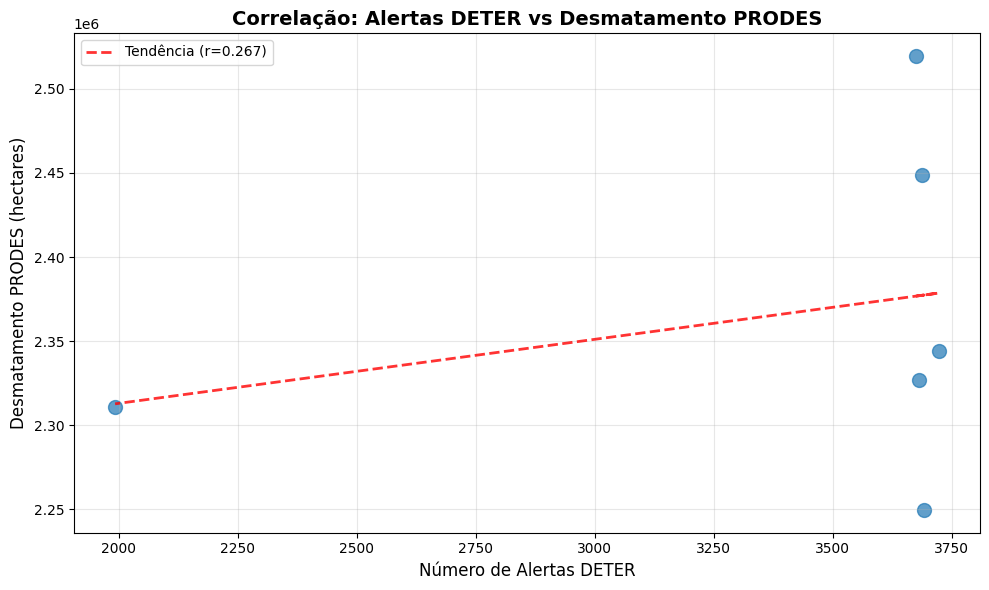

2026-05-16 14:57:06,382 - INFO -   Gráfico gerado: dispersão com linha de tendência


In [8]:
logger.info("\n--- VISUALIZAÇÃO DA CORRELAÇÃO ---")

# Visualizar correlação
plt.figure(figsize=(10, 6))

plt.scatter(df_merge['num_alertas'], 
            df_merge['desmatamento_ha_total'], 
            alpha=0.7, s=100)

# Adicionar linha de tendência
z = np.polyfit(df_merge['num_alertas'], df_merge['desmatamento_ha_total'], 1)
p = np.poly1d(z)
plt.plot(df_merge['num_alertas'], 
         p(df_merge['num_alertas']), 
         "r--", alpha=0.8, linewidth=2, 
         label=f'Tendência (r={correlacao:.3f})')

plt.xlabel('Número de Alertas DETER', fontsize=12)
plt.ylabel('Desmatamento PRODES (hectares)', fontsize=12)
plt.title('Correlação: Alertas DETER vs Desmatamento PRODES', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logger.info("  Gráfico gerado: dispersão com linha de tendência")

logger.info("\n--- CONCLUSÃO DA ANÁLISE 2 ---")

# Preencher conclusão com base nos resultados
if abs(correlacao) > 0.7:
    texto_forca = "FORTE"
    texto_preditivo = "é um bom preditor"
elif abs(correlacao) > 0.3:
    texto_forca = "MODERADA"
    texto_preditivo = "tem valor preditivo parcial"
else:
    texto_forca = "FRACA"
    texto_preditivo = "pode não ser um bom preditor"

### Conclusão da Análise 2

**Interpretação de Negócio:**
- A correlação de [X.XX] entre alertas DETER e desmatamento PRODES é [FORTE/MODERADA/FRACA]
- Isso indica que [DETER é/não é] um bom preditor de desmatamento futuro
- Recomendação: [usar DETER para ação preventiva / complementar com outras fontes]

logger.info(f"\n  RESUMO EXECUTIVO:")
logger.info(f"  • Correlação Pearson: {correlacao:.4f} ({texto_forca})")
logger.info(f"  • Correlação Spearman: {correlacao_spearman:.4f}")
logger.info(f"  • Significância estatística: {'Sim' if p_value_corr < 0.05 else 'Não'} (p={p_value_corr:.4f})")
logger.info(f"  • Intervalo de confiança 95%: [{r_lower:.4f}, {r_upper:.4f}]")
logger.info(f"  • DETER {texto_preditivo} de desmatamento futuro")

---
## Resumo do Eixo 1: Desmatamento e Fogo

**Principais Descobertas:**
1. Tendência temporal do desmatamento: [CRESCENTE/DECRESCENTE/ESTACIONÁRIA]
2. Correlação DETER-PRODES: [FORTE/MODERADA/FRACA]

**Implicações de Negócio:**
- [Insights específicos baseados nos resultados]
- [Recomendações de ação]

**Próximos Passos:**
- [Análises adicionais recomendadas]
- [Fontes de dados a integrar]

logger.info("\n" + "="*80)
logger.info("FIM DO EIXO 1: Desmatamento e Fogo")
logger.info("="*80)